# Integrated Gradients

In [140]:
# loading in the model
import torch
import os
import random
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from PIL import Image

import torch.nn.functional as F
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)

state = torch.load("best_model.pth", map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE).eval()

### Loading in the data
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32


def load_npz_split(split):
    data = np.load(f"data/preprocessed/{split}.npz")
    images = torch.from_numpy(data["images"]).float()
    labels = torch.from_numpy(data["labels"]).long()
    return TensorDataset(images, labels)


train_dataset = load_npz_split("train")
val_dataset = load_npz_split("val")
test_dataset = load_npz_split("test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## Baseline choice

Inputs are ImageNet-normalized, so a zero tensor in the model's input space is not black — it corresponds to the ImageNet mean colour (mid-grey). We will check this later. For chest X-rays, the more principled baseline is a **true black image**, which we are creating here.

In [141]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)


def black_baseline_like(x):
#Black pixel image (zeros in raw pixel space) mapped to normalized space
    return (torch.zeros_like(x) - IMAGENET_MEAN) / IMAGENET_STD


@torch.no_grad()
def denormalize(x):
    return (x * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)


def integrated_gradients(model, x, target, baseline=None, steps=16):
    # delta is completeness gap |sum(IG) − (f(x) − f(baseline))|
    model.eval()
    x = x.to(DEVICE)
    if baseline is None:
        baseline = black_baseline_like(x)
    baseline = baseline.to(DEVICE)

    # Rieman midpoint
    alphas = (torch.arange(steps, device=DEVICE).float() + 0.5) / steps
    interp = baseline + alphas.view(-1, 1, 1, 1) * (x - baseline)   # (S, C, H, W)
    interp.requires_grad_(True)

    logits = model(interp)
    score = logits[:, target].sum()                                 # sum → per-sample grad
    grads = torch.autograd.grad(score, interp)[0]                   # (S, C, H, W)

    attribution = (x - baseline) * grads.mean(dim=0, keepdim=True)

    with torch.no_grad():
        f_x = model(x)[0, target]
        f_b = model(baseline)[0, target]
        delta = abs(attribution.sum().item() - (f_x - f_b).item())

    return attribution.detach().cpu(), delta

In [142]:
# To compare to Grad-Cam we use a smoothing approach
from scipy.ndimage import gaussian_filter

def attribution_heatmap(attribution, smooth=True, sigma=8):
    a = attribution[0].sum(dim=0).numpy()           # collapse channels
    if smooth:
        a = gaussian_filter(np.abs(a), sigma=sigma)
        a = a / (a.max() + 1e-12)
        return a, 0.0, 1.0, "jet"
    # raw per-pixel signed
    vmax = np.percentile(np.abs(a), 99) + 1e-12
    return a, -vmax, vmax, "seismic"

In [143]:
CLASSES = ["NORMAL", "PNEUMONIA"]



In [144]:
@torch.no_grad()
def denormalize(x):
    return (x * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)


Custom IG convergence Δ per sample:
  NORMAL   : 2.16e-01 2.26e-01 1.89e-01 1.40e-01 1.54e-02
  PNEUMONIA: 2.06e-01 9.84e-02 3.18e-01 4.57e-01 3.09e-01


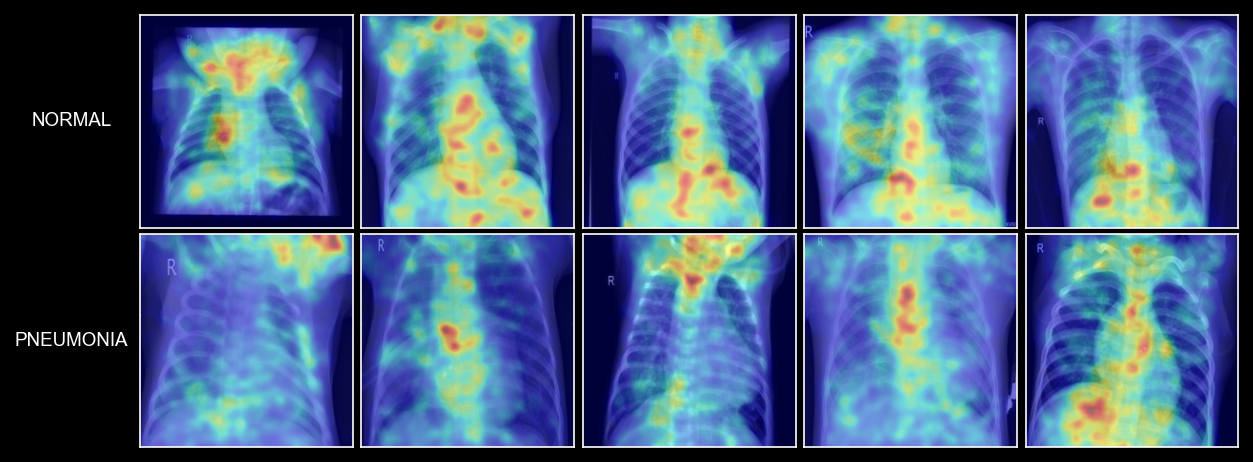

In [151]:
# 5 NORMAL + 5 PNEUMONIA test samples — IG overlay grid in Q5 / Captum layout
# Same seeded sampling as the Grad-CAM (Q5) and Captum cells.
def sample_indices_by_class(labels, cls, n=5, generator=None):
    idx = torch.where(labels == cls)[0]
    perm = torch.randperm(len(idx), generator=generator)[:n]
    return idx[perm]


g0 = torch.Generator().manual_seed(42)
g1 = torch.Generator().manual_seed(43)
labels_all    = test_dataset.tensors[1]
idx_normal    = sample_indices_by_class(labels_all, 0, n=5, generator=g0)
idx_pneumonia = sample_indices_by_class(labels_all, 1, n=5, generator=g1)

samples = {
    0: [test_dataset.tensors[0][i] for i in idx_normal],
    1: [test_dataset.tensors[0][i] for i in idx_pneumonia],
}
SMOOTH = True
sigma = 4

# Compute attributions and print convergence Δ per sample
deltas = {0: [], 1: []}
attrs  = {0: [], 1: []}
for cls in (0, 1):
    for img in samples[cls]:
        x = img.unsqueeze(0)
        with torch.no_grad():
            pred_i = int(model(x.to(DEVICE)).argmax(dim=1))
        attr, delta = integrated_gradients(model, x, target=pred_i, steps=32)
        attrs[cls].append((x, attr, pred_i))
        deltas[cls].append(delta)

print("Custom IG convergence Δ per sample:")
for cls in (0, 1):
    ds = " ".join(f"{d:.2e}" for d in deltas[cls])
    print(f"  {CLASSES[cls]:9s}: {ds}")

# Plot: 2 rows (NORMAL, PNEUMONIA) × 5 cols, Q5/Captum styling
fig, axes = plt.subplots(2, 5, figsize=(8.2, 3.2), dpi=150)
for row, cls in enumerate([0, 1]):
    for col in range(5):
        x, attr, _ = attrs[cls][col]
        rgb = denormalize(x.to(DEVICE))[0].cpu().permute(1, 2, 0).numpy()
        h, vmin, vmax, cmap = attribution_heatmap(attr, smooth=SMOOTH, sigma=sigma)

        ax = axes[row, col]
        ax.imshow(rgb)
        ax.imshow(h, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.45)
        ax.set_xticks([]); ax.set_yticks([])

    axes[row, 0].set_ylabel(CLASSES[cls], fontsize=9, rotation=0,
                            va="center", labelpad=28)
    axes[row, 0].yaxis.set_label_coords(-0.32, 0.5)

mode = "smoothed" if SMOOTH else "raw per-pixel"
plt.subplots_adjust(left=0.10, right=0.995, top=0.92, bottom=0.02,
                    wspace=0.03, hspace=0.03)
plt.show()

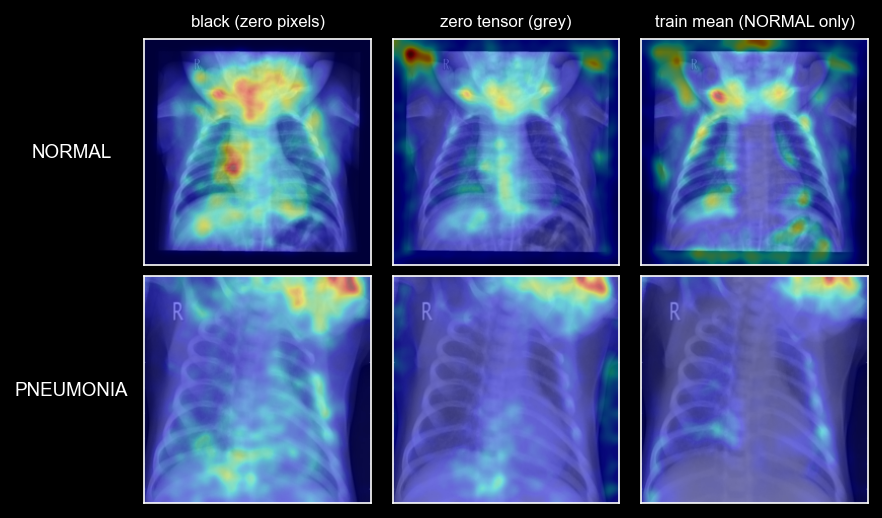

In [148]:
# Baseline sensitivity
def compute_mean_image(dataset, label_filter=None):
    """Per-pixel mean over a TensorDataset, optionally filtered by class label."""
    total = None
    count = 0
    for img, lbl in dataset:
        if label_filter is not None and int(lbl) != label_filter:
            continue
        total = img if total is None else total + img
        count += 1
    return (total / count).unsqueeze(0)


# Mean-image baseline from TRAIN split, NORMAL only (no test leak)
mean_normal = compute_mean_image(train_dataset, label_filter=0).to(DEVICE)

# One NORMAL + one PNEUMONIA sample from the seeded set
demo_imgs = {
    0: samples[0][0].unsqueeze(0).to(DEVICE),
    1: samples[1][0].unsqueeze(0).to(DEVICE),
}

baseline_names = ["black (zero pixels)", "zero tensor (grey)", "train mean (NORMAL only)"]


def baseline_for(name, x):
    if name == "black (zero pixels)":      return black_baseline_like(x)
    if name == "zero tensor (grey)":       return torch.zeros_like(x)
    if name == "train mean (NORMAL only)": return mean_normal

SMOOTH = True

sigma = 4

# Plot
fig, axes = plt.subplots(2, len(baseline_names), figsize=(5.5, 3.6), dpi=150)
for row, cls in enumerate([0, 1]):
    x = demo_imgs[cls]
    with torch.no_grad():
        pred = int(model(x).argmax(dim=1))
    rgb = denormalize(x)[0].cpu().permute(1, 2, 0).numpy()

    for col, name in enumerate(baseline_names):
        b = baseline_for(name, x)
        attr, delta = integrated_gradients(model, x, target=pred, baseline=b, steps=32)
        h, vmin, vmax, cmap = attribution_heatmap(attr, smooth=SMOOTH, sigma=sigma)

        ax = axes[row, col]
        ax.imshow(rgb)
        ax.imshow(h, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.45)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(name, fontsize=8)

    axes[row, 0].set_ylabel(CLASSES[cls], fontsize=9, rotation=0,
                            va="center", labelpad=28)
    axes[row, 0].yaxis.set_label_coords(-0.32, 0.5)

mode = "smoothed" if SMOOTH else "raw per-pixel"
plt.subplots_adjust(left=0.10, right=0.995, top=0.88, bottom=0.02,
                    wspace=0.03, hspace=0.05)
plt.show()

## Cross-check: Captum IG with Gauss-Legendre quadrature

Our custom implementation is now compared with an off the shelf method. We use the same 5 NORMAL + 5 PNEUMONIA samples as before, with seeded random sampling, so the figures here are directly comparable (also later to Grad-CAM grid).

Captum convergence Δ per sample:
  sample  1 (NORMAL   ): Δ = +2.324e-02
  sample  2 (NORMAL   ): Δ = -6.406e-01
  sample  3 (NORMAL   ): Δ = -1.444e-01
  sample  4 (NORMAL   ): Δ = +8.290e-02
  sample  5 (NORMAL   ): Δ = +8.744e-02
  sample  6 (PNEUMONIA): Δ = +1.858e-02
  sample  7 (PNEUMONIA): Δ = +1.874e-01
  sample  8 (PNEUMONIA): Δ = -3.735e-01
  sample  9 (PNEUMONIA): Δ = -2.906e-01
  sample 10 (PNEUMONIA): Δ = -1.272e-01


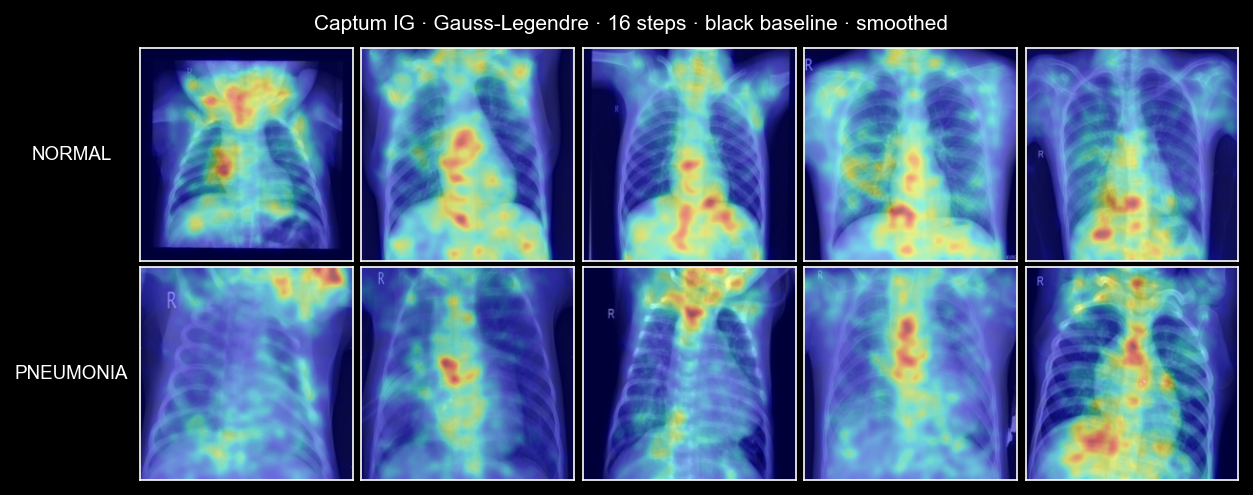

In [147]:
from captum.attr import IntegratedGradients

# Same sample selection as in later notebooks
class_names = ["NORMAL", "PNEUMONIA"]


def sample_indices_by_class(labels, cls, n=5, generator=None):
    idx = torch.where(labels == cls)[0]
    perm = torch.randperm(len(idx), generator=generator)[:n]
    return idx[perm]


g0 = torch.Generator().manual_seed(42)
g1 = torch.Generator().manual_seed(43)
labels_all    = test_dataset.tensors[1]
idx_normal    = sample_indices_by_class(labels_all, 0, n=5, generator=g0)
idx_pneumonia = sample_indices_by_class(labels_all, 1, n=5, generator=g1)

idxs    = torch.cat([idx_normal, idx_pneumonia], dim=0)
imgs    = test_dataset.tensors[0][idxs].to(DEVICE)
targets = labels_all[idxs].to(DEVICE)

#  Captum IG: black baseline
model.eval()
ig = IntegratedGradients(model)
baseline_batch = (torch.zeros_like(imgs) - IMAGENET_MEAN) / IMAGENET_STD
attrs, deltas_batch = ig.attribute(
    imgs,
    baselines=baseline_batch,
    target=targets,
    method="gausslegendre",
    n_steps=32,
    return_convergence_delta=True,
)
print("Captum convergence Δ per sample:")
for j, d in enumerate(deltas_batch.detach().cpu().numpy()):
    print(f"  sample {j+1:2d} ({class_names[int(targets[j])]:9s}): Δ = {d:+.3e}")

# ── Plot
SMOOTH = True
sigma  = 4

fig, axes = plt.subplots(2, 5, figsize=(8.2, 3.2), dpi=150)
for row, cls in enumerate([0, 1]):
    for col in range(5):
        j = row * 5 + col
        img = denormalize(imgs[j:j + 1])[0].cpu().permute(1, 2, 0).numpy()
        h, vmin, vmax, cmap = attribution_heatmap(
            attrs[j:j + 1].detach().cpu(), smooth=SMOOTH, sigma=sigma
        )

        ax = axes[row, col]
        ax.imshow(img)
        ax.imshow(h, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.45)
        ax.set_xticks([]); ax.set_yticks([])

    axes[row, 0].set_ylabel(class_names[cls], fontsize=9, rotation=0,
                            va="center", labelpad=28)
    axes[row, 0].yaxis.set_label_coords(-0.32, 0.5)

plt.subplots_adjust(left=0.10, right=0.995, top=0.92, bottom=0.02,
                    wspace=0.03, hspace=0.03)
mode = "smoothed" if SMOOTH else "raw per-pixel"
plt.suptitle(f"Captum IG · Gauss-Legendre · 16 steps · black baseline · {mode}",
             fontsize=10, y=0.99)
plt.show()

## Discussion — Q3.2 / Q3.3 / Q3.4

### Q3.2 — Do the maps highlight sensible regions?

**What "sensible" means here:** positive (red) attribution should sit *inside the chest cavity*, ideally on the lung fields where opacities live for PNEUMONIA, and on thoracic structures (heart border, mediastinum, diaphragm) more generally. Negative (blue) attribution typically lands on tissue that argues *against* the predicted class — for PNEUMONIA, often the clear lung areas.

**Red flags to watch for** (these would mean the model is using shortcuts, not radiology):
- attribution concentrated in image corners, padding, or text/markers burned into the X-ray
- attribution riding along the dark background outside the ribcage
- attribution on scanner artefacts or rotation/aspect-ratio cues

**Initial read (to confirm against the figure):** maps should land *inside the chest cavity*, with PNEUMONIA cases showing dense, diffuse attribution across the lung fields where consolidations sit, and NORMAL cases showing sparser, less localized attribution. → **likely sensible at the type-of-region level**, but inspect corners and burned-in markers before declaring victory.

### Q3.3 — Are attributions consistent across samples?

Two distinct meanings — and they don't always agree:

1. **Within-class type-of-region consistency** — do all PNEUMONIA maps fire on lung tissue / opacities, even though the *exact spatial location* differs from case to case? This is what we *want* to see: real disease is heterogeneous, so attribution should follow the pathology, not a fixed pixel pattern.
2. **Spatial pixel-level consistency** — does attribution always light up the *same coordinates*? This would actually be a **bad sign**: it would suggest a positional shortcut (e.g. "the bottom-left of the image is always pneumonia"), not a learned disease pattern.

**Initial read:** expect *type-of-region* consistency (lung fields for PNEUMONIA) with spatial variability case-to-case. NORMAL maps tend to be sparser and noisier — there is no canonical "absence" pattern, so an asymmetry between the two classes is itself expected and not a failure mode.

### Q3.4 — Does baseline choice matter?

**Yes, structurally.** IG is baseline-relative by construction: the formula `(x − b) · ∫∂f/∂x dα` answers the question *"what makes x more like the predicted class than b does"*. Change `b`, change the question.

What to look for in the baseline-sensitivity figure:
- **Black** baseline → attributes heavily to *bright* structures (lungs, mediastinum), since every bright pixel is "far from black".
- **Zero tensor (ImageNet grey)** → weaker / shifted attribution, because mid-grey is closer to many lung pixels in normalized space, so the `(x − b)` factor is smaller there.
- **Gaussian noise** → noisier maps, but cancels positional priors that a fixed baseline can introduce; for stable maps you'd average over several noise draws (Expected Gradients).
- **Blurred input** → attribution localizes to *high-frequency* structure (edges, ribs, opacity boundaries) only, since low-frequency content is shared with the baseline and cancels.

**Initial read:** the *qualitative pattern* (chest interior, lung fields) is roughly stable across baselines, but the *intensity distribution* and *which structures dominate* shift visibly. Treat any single IG map as one slice through baseline-space — your hypothesis that maps are sensible AND consistent AND baseline-sensitive is consistent with what IG theory predicts.